# Notebook 02 — Intra-ESI Risk Model Validation

**Project:** IntraSight-ESI — Clinical Triage Decision Support  
**Question:** Within ESI 3, 4, and 5, can we identify patients at elevated risk of hospitalization, transfer, or death using only triage-available data?  
**Data:** NHAMCS 2016–2022 (N=54,744 ED visits, ESI 3–5 only)  

This notebook does **not** demonstrate that LightGBM is impressive. It tests whether a real intra-ESI signal exists, is not explained by leakage, and whether an ML model outperforms simple clinical rules that any triagist could apply by hand.  

**Metrics are reported per ESI separately. No combined metrics.**

---
## Section 0 — Setup

In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings; warnings.filterwarnings('ignore')
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import lightgbm as lgb
import shap
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import resample

# Paths
BASE_DIR  = Path(r'C:\Users\pablo\OneDrive\Desktop\triagegeist_submission')
DATA_DIR  = BASE_DIR / 'data' / 'processed'
REPORT_DIR = BASE_DIR / 'reports' / '02_model_validation'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Setup complete.')


Setup complete.


In [3]:
# Load processed dataset (output of NB01)
df = pd.read_csv(DATA_DIR / 'nhamcs_pooled_2016_2022.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# Verify all expected columns are present
EXPECTED = [
    'year', 'esi', 'outcome', 'ADMITHOS', 'TRANOTH', 'DIEDED',
    'AGE', 'SEX', 'ARREMS', 'temp_f', 'PULSE', 'RESPR',
    'BPSYS', 'BPDIAS', 'POPCT', 'PAINSCALE', 'RFV1', 'RFV2',
    'shock_index', 'age_65plus', 'age_shock_index',
    'tachycardia_flag', 'tachypnea_flag', 'hypotension_flag',
    'hypoxemia_flag', 'fever_flag', 'bp_missing_flag', 'any_vital_missing_flag',
    'ASTHMA', 'CANCER', 'COPD', 'CHF', 'DEPRN', 'DIABTYP1', 'DIABTYP2',
    'ESRD', 'EDHIV', 'HTN', 'OBESITY', 'SUBSTAB', 'comorbidity_count',
    'RACERETH', 'PAYTYPER', 'NUMMED',
]
missing_cols = [c for c in EXPECTED if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}')
print('All 44 expected columns present.')

# Immediate ESI split — IMMEDR/esi used ONLY as filter, never as predictor
df_3 = df[df['esi'] == 3].copy().reset_index(drop=True)
df_4 = df[df['esi'] == 4].copy().reset_index(drop=True)
df_5 = df[df['esi'] == 5].copy().reset_index(drop=True)
print(f'ESI 3: {len(df_3):,}  |  ESI 4: {len(df_4):,}  |  ESI 5: {len(df_5):,}')
print(f'Base rates — ESI3: {df_3["outcome"].mean():.3f}  '
      f'ESI4: {df_4["outcome"].mean():.3f}  ESI5: {df_5["outcome"].mean():.3f}')


Loaded: 54,744 rows x 44 columns
All 44 expected columns present.
ESI 3: 31,460  |  ESI 4: 20,182  |  ESI 5: 3,102
Base rates — ESI3: 0.135  ESI4: 0.025  ESI5: 0.035


---
## Section 1 — Feature Set Definitions and Methodological Notes

### Three feature sets

**Set A — Triage-only strict (principal model)**  
All variables available at the moment of triage, without requiring access to the patient's medical history. This is the operationally valid model for any ED.

**Set B — EHR-at-triage (secondary model)**  
Set A plus individual comorbidities and the comorbidity count. Assumes the triage nurse has access to the patient's electronic health record at the time of triage. This assumption is declared explicitly — it does not hold in all EDs.  

> **Why `comorbidity_count` lives in Set B, not Set A:**  
> `comorbidity_count` is derived by summing 12 individual binary comorbidity fields (ASTHMA, CANCER, COPD, CHF, DEPRN, DIABTYP1, DIABTYP2, ESRD, EDHIV, HTN, OBESITY, SUBSTAB). Knowing how many chronic conditions a patient has requires knowing *which* conditions they have — which requires EHR access. Asking a patient "how many chronic diseases do you have?" at triage produces unreliable self-report, not the structured clinical coding these NHAMCS variables represent. Therefore `comorbidity_count` is methodologically inseparable from Set B.

**Set C — Leaky positive control (demonstration only)**  
Set B plus `NUMMED` (medications given or prescribed *during* the visit — recorded after triage). Included solely to demonstrate how much AUC inflates with temporal leakage. Set C is never a candidate for deployment.

> **Note:** `RACERETH`, `PAYTYPER`, and `year` are **excluded from all predictive models**. Using race or insurance type as a clinical risk predictor is ethically indefensible in a triage support system. These variables appear only in the fairness audit (Notebook 04).

In [4]:
# Feature set definitions — single source of truth for the entire notebook

FEATURES_A = [
    # Demographics
    'AGE', 'SEX', 'ARREMS',
    # Triage vitals
    'temp_f', 'PULSE', 'RESPR', 'BPSYS', 'BPDIAS', 'POPCT', 'PAINSCALE',
    # Reason for visit
    'RFV1', 'RFV2',
    # Derived: hemodynamic
    'shock_index', 'age_65plus', 'age_shock_index',
    # Derived: vital flags (NaN → 0)
    'tachycardia_flag', 'tachypnea_flag', 'hypotension_flag',
    'hypoxemia_flag', 'fever_flag',
    # Derived: informative missingness flags (NaN → 1)
    'bp_missing_flag', 'any_vital_missing_flag',
]

FEATURES_B = FEATURES_A + [
    # Individual comorbidities (requires EHR)
    'ASTHMA', 'CANCER', 'COPD', 'CHF', 'DEPRN', 'DIABTYP1', 'DIABTYP2',
    'ESRD', 'EDHIV', 'HTN', 'OBESITY', 'SUBSTAB',
    # Derived: comorbidity burden (requires EHR — see methodological note)
    'comorbidity_count',
]

FEATURES_C = FEATURES_B + [
    'NUMMED',  # Post-triage leakage — demonstration only
]

# Sanity check: outcome and ESI must NOT appear in any feature set
FORBIDDEN = {'outcome', 'esi', 'ADMITHOS', 'TRANOTH', 'DIEDED',
             'RACERETH', 'PAYTYPER', 'year'}
for name, fset in [('A', FEATURES_A), ('B', FEATURES_B), ('C', FEATURES_C)]:
    leaked = FORBIDDEN.intersection(set(fset))
    assert not leaked, f'Set {name} contains forbidden columns: {leaked}'

print(f'Set A: {len(FEATURES_A)} features (triage-only strict)')
print(f'Set B: {len(FEATURES_B)} features (EHR-at-triage)')
print(f'Set C: {len(FEATURES_C)} features (leaky positive control)')
print('Leakage check passed — no forbidden columns in any set.')


Set A: 22 features (triage-only strict)
Set B: 35 features (EHR-at-triage)
Set C: 36 features (leaky positive control)
Leakage check passed — no forbidden columns in any set.


---
## Section 2 — Harvard Filter Audit (Raita 2019 Exclusion Criteria)

Physiologically impossible values are converted to NaN at this stage, following the exclusion thresholds from Raita et al. 2019 (Critical Care). These filters were already applied during NB01 ingestion, so the counts below should be zero — this cell confirms it on the final dataset.

In [5]:
# Harvard exclusion criteria (Raita 2019, Critical Care)
# Applied during NB01 ingestion — this cell audits the final dataset
HARVARD_FILTERS = [
    ('BPSYS',  'BPSYS > 300',  lambda s: s > 300),
    ('BPDIAS', 'BPDIAS > 200', lambda s: s > 200),
    ('PULSE',  'PULSE > 300',  lambda s: s > 300),
    ('RESPR',  'RESPR > 80',   lambda s: s > 80),
    ('POPCT',  'POPCT > 100',  lambda s: s > 100),
]

total_excluded = 0
print(f'Harvard filter audit on N={len(df):,} rows')
print(f'  {"Criterion":<20}  {"N violating":>12}  {"Action"}')
for col, label, fn in HARVARD_FILTERS:
    n_viol = int(fn(df[col].dropna()).sum())
    total_excluded += n_viol
    print(f'  {label:<20}  {n_viol:>12,}  set to NaN during NB01')

print(f'\nTotal physiologically impossible values: {total_excluded}')
if total_excluded == 0:
    print('Harvard filters already applied in NB01 — dataset is clean.')
else:
    print('WARNING: applying filters now.')
    for col, label, fn in HARVARD_FILTERS:
        mask = fn(df[col])
        df.loc[mask, col] = np.nan
        df_3.loc[df_3['esi'] == 3, col] = np.nan
    print(f'Filters applied. Final N: {len(df):,}')


Harvard filter audit on N=54,744 rows
  Criterion              N violating  Action
  BPSYS > 300                      0  set to NaN during NB01
  BPDIAS > 200                     0  set to NaN during NB01
  PULSE > 300                      0  set to NaN during NB01
  RESPR > 80                       0  set to NaN during NB01
  POPCT > 100                      0  set to NaN during NB01

Total physiologically impossible values: 0
Harvard filters already applied in NB01 — dataset is clean.


---
## Section 3 — Clinical Baseline Rules

Before any machine learning, we benchmark against simple clinical rules that any triage nurse could apply by hand. The LightGBM model must outperform these baselines to justify its existence. If it does not, the simpler rule is preferable.

For each rule, we report: N flagged, PPV (outcome rate in flagged group), base rate, enrichment (PPV / base rate), and alert burden (% of ESI patients flagged).

In [6]:
def baseline_rule(sub, mask, rule_name, esi):
    """Compute PPV / enrichment / burden for a boolean mask within ESI sub."""
    n_total = len(sub)
    n_flag  = int(mask.sum())
    base_rate = sub['outcome'].mean()
    if n_flag == 0:
        return {'rule': rule_name, 'esi': esi, 'n_flagged': 0,
                'n_outcomes': 0, 'ppv': np.nan, 'base_rate': round(base_rate, 4),
                'enrichment': np.nan, 'alert_burden_pct': 0.0}
    n_outcomes = int(sub.loc[mask, 'outcome'].sum())
    ppv = n_outcomes / n_flag
    return {
        'rule': rule_name, 'esi': esi,
        'n_flagged': n_flag,
        'n_outcomes': n_outcomes,
        'ppv': round(ppv, 4),
        'base_rate': round(base_rate, 4),
        'enrichment': round(ppv / base_rate, 3),
        'alert_burden_pct': round(n_flag / n_total * 100, 1),
    }

RULES = [
    ('age_65plus',                    lambda s: s['age_65plus'] == 1),
    ('hypoxemia_flag',                lambda s: s['hypoxemia_flag'] == 1),
    ('age_65plus OR hypoxemia_flag',  lambda s: (s['age_65plus'] == 1) | (s['hypoxemia_flag'] == 1)),
    ('age_65plus AND hypoxemia_flag', lambda s: (s['age_65plus'] == 1) & (s['hypoxemia_flag'] == 1)),
    ('bp_not_missing',                lambda s: s['bp_missing_flag'] == 0),
    ('comorbidity_count >= 2',        lambda s: s['comorbidity_count'] >= 2),
]

baseline_rows = []
for esi, sub in [(3, df_3), (4, df_4), (5, df_5)]:
    for rule_name, fn in RULES:
        baseline_rows.append(baseline_rule(sub, fn(sub), rule_name, esi))

df_baselines = pd.DataFrame(baseline_rows)
df_baselines.to_csv(REPORT_DIR / '02_baselines_clinical_rules.csv', index=False)

print('Clinical Baselines — Enrichment over ESI Base Rate')
print('='*90)
for esi in [3, 4, 5]:
    sub = df_baselines[df_baselines['esi'] == esi]
    br  = sub['base_rate'].iloc[0]
    print(f'\nESI {esi}  (base rate: {br:.3f})')
    print(f'  {"Rule":<35}  {"N flagged":>10}  {"PPV":>7}  {"Enrich":>8}  {"Burden%":>8}')
    print('  ' + '-'*74)
    for _, row in sub.iterrows():
        print(f'  {row["rule"]:<35}  {row["n_flagged"]:>10,}  '
              f'{row["ppv"]:>7.3f}  {row["enrichment"]:>8.2f}x  {row["alert_burden_pct"]:>7.1f}%')

print('\nSaved: 02_baselines_clinical_rules.csv')
print('The LightGBM model must exceed the best single rule enrichment at comparable burden.')


Clinical Baselines — Enrichment over ESI Base Rate

ESI 3  (base rate: 0.135)
  Rule                                  N flagged      PPV    Enrich   Burden%
  --------------------------------------------------------------------------
  age_65plus                                6,264    0.284      2.10x     19.9%
  hypoxemia_flag                            1,443    0.315      2.34x      4.6%
  age_65plus OR hypoxemia_flag              7,060    0.275      2.04x     22.4%
  age_65plus AND hypoxemia_flag               647    0.451      3.35x      2.1%
  bp_not_missing                           29,379    0.139      1.03x     93.4%
  comorbidity_count >= 2                    7,374    0.251      1.86x     23.4%

ESI 4  (base rate: 0.025)
  Rule                                  N flagged      PPV    Enrich   Burden%
  --------------------------------------------------------------------------
  age_65plus                                1,793    0.084      3.36x      8.9%
  hypoxemia_flag       

---
## Section 4 — Validation Design: Leave-One-Year-Out (LOYO)

**5 folds**: 2016, 2017, 2018, 2019, 2022 — each year serves as the test set once.

**Early stopping protocol (critical — temporal leakage prevention):**  
Early stopping uses the most recent year in the training set as an internal validation set — **not** the held-out test year. If test=2022, then train=2016–2019, early stopping on 2019, and effective training on 2016–2018. Using the test year for early stopping would be subtle temporal leakage.

**Why LOYO instead of KFold?**  
LOYO simulates prospective deployment: the model is trained on past data and evaluated on future unseen data. This is the correct validation paradigm for a system intended for ongoing clinical use.

In [7]:
YEARS = [2016, 2017, 2018, 2019, 2022]

def get_loyo_splits(df_esi):
    """Generate LOYO fold indices with internal early-stopping split.
    Returns list of (train_idx, val_idx, test_idx, test_year) tuples.
    """
    splits = []
    for test_year in YEARS:
        train_years  = [y for y in YEARS if y != test_year]
        val_year     = max(train_years)        # most recent year in train
        eff_train_yrs = [y for y in train_years if y != val_year]

        train_idx = df_esi.index[df_esi['year'].isin(eff_train_yrs)].tolist()
        val_idx   = df_esi.index[df_esi['year'] == val_year].tolist()
        test_idx  = df_esi.index[df_esi['year'] == test_year].tolist()

        splits.append((train_idx, val_idx, test_idx, test_year))
    return splits

# Preview split sizes for ESI 3
print('LOYO split preview — ESI 3')
print(f'  {"Test year":<12}  {"Eff. train N":>13}  {"Val N":>7}  {"Test N":>7}')
for train_idx, val_idx, test_idx, test_year in get_loyo_splits(df_3):
    print(f'  test={test_year}      {len(train_idx):>13,}  {len(val_idx):>7,}  {len(test_idx):>7,}')


LOYO split preview — ESI 3
  Test year      Eff. train N    Val N   Test N
  test=2016             19,594    5,340    6,526
  test=2017             20,361    5,340    5,759
  test=2018             19,166    5,340    6,954
  test=2019             19,239    5,340    6,881
  test=2022             19,239    6,881    5,340


---
## Section 5 — Model Training: Set A (Triage-Only Strict)

LightGBM trained separately for ESI 3, 4, and 5. LOYO cross-validation with early stopping on internal validation set (see Section 4). `scale_pos_weight` handles class imbalance without artificial resampling.

In [8]:
def get_lgbm_params(n_neg, n_pos):
    """LightGBM base parameters with class imbalance correction."""
    return dict(
        objective='binary',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        min_child_samples=30,
        scale_pos_weight=n_neg / n_pos,
        metric='average_precision',
        verbosity=-1,
        random_state=RANDOM_STATE,
    )

def bootstrap_auc(y_true, y_score, metric_fn, n_boot=1000, seed=42):
    """Bootstrap 95% CI for a metric function."""
    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if y_true[idx].sum() == 0:
            continue
        scores.append(metric_fn(y_true[idx], y_score[idx]))
    return np.percentile(scores, [2.5, 97.5])

def train_loyo(df_esi, features, esi_label):
    """LOYO training loop. Returns OOF predictions and per-fold metrics."""
    oof_preds  = np.full(len(df_esi), np.nan)
    fold_aucs  = []
    fold_pr    = []
    n_pos = int(df_esi['outcome'].sum())
    n_neg = len(df_esi) - n_pos
    params = get_lgbm_params(n_neg, n_pos)

    for train_idx, val_idx, test_idx, test_year in get_loyo_splits(df_esi):
        if not test_idx:
            continue
        X_tr  = df_esi.loc[train_idx, features]
        y_tr  = df_esi.loc[train_idx, 'outcome']
        X_val = df_esi.loc[val_idx,   features]
        y_val = df_esi.loc[val_idx,   'outcome']
        X_te  = df_esi.loc[test_idx,  features]
        y_te  = df_esi.loc[test_idx,  'outcome']

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)],
        )
        preds = model.predict_proba(X_te)[:, 1]
        oof_preds[test_idx] = preds

        if y_te.sum() > 0:
            fold_aucs.append(roc_auc_score(y_te, preds))
            fold_pr.append(average_precision_score(y_te, preds))

        print(f'  ESI {esi_label} | test={test_year} | '
              f'ROC={fold_aucs[-1]:.4f} PR={fold_pr[-1]:.4f} '
              f'(n_test={len(test_idx):,}, n_pos={int(y_te.sum())})')

    return oof_preds, fold_aucs, fold_pr

def oof_metrics(df_esi, oof_preds, esi_label):
    """Compute global OOF metrics including enrichment at top 10%."""
    y_true = df_esi['outcome'].values
    valid  = ~np.isnan(oof_preds)
    y_v, p_v = y_true[valid], oof_preds[valid]

    roc = roc_auc_score(y_v, p_v)
    pr  = average_precision_score(y_v, p_v)
    roc_ci = bootstrap_auc(y_v, p_v, roc_auc_score)
    pr_ci  = bootstrap_auc(y_v, p_v, average_precision_score)

    # Enrichment at top 10%
    threshold = np.percentile(p_v, 90)
    top10_mask = p_v >= threshold
    base_rate  = y_v.mean()
    ppv_top10  = y_v[top10_mask].mean() if top10_mask.sum() > 0 else np.nan
    enrichment = ppv_top10 / base_rate if base_rate > 0 else np.nan

    return {
        'esi': esi_label,
        'n': int(valid.sum()),
        'n_pos': int(y_v.sum()),
        'base_rate': round(base_rate, 4),
        'roc_auc': round(roc, 4),
        'roc_ci_lo': round(roc_ci[0], 4),
        'roc_ci_hi': round(roc_ci[1], 4),
        'pr_auc': round(pr, 4),
        'pr_ci_lo': round(pr_ci[0], 4),
        'pr_ci_hi': round(pr_ci[1], 4),
        'ppv_top10pct': round(ppv_top10, 4),
        'enrichment_top10pct': round(enrichment, 3),
    }


In [9]:
# Train Set A — ESI 3, 4, 5
print('=== SET A TRAINING (triage-only strict) ===')
results_A  = {}
oof_A      = {}

for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    print(f'\n--- ESI {esi} ---')
    oof_preds, fold_aucs, fold_pr = train_loyo(df_esi, FEATURES_A, esi)
    oof_A[esi] = oof_preds
    metrics = oof_metrics(df_esi, oof_preds, esi)
    metrics['set'] = 'A'
    results_A[esi] = metrics
    print(f'  OOF ROC AUC: {metrics["roc_auc"]:.4f} '
          f'[{metrics["roc_ci_lo"]:.4f}–{metrics["roc_ci_hi"]:.4f}]')
    print(f'  OOF PR  AUC: {metrics["pr_auc"]:.4f} '
          f'[{metrics["pr_ci_lo"]:.4f}–{metrics["pr_ci_hi"]:.4f}]')
    print(f'  Enrichment @Top10%: {metrics["enrichment_top10pct"]:.2f}x '
          f'(PPV={metrics["ppv_top10pct"]:.3f} vs base={metrics["base_rate"]:.3f})')

print('\nSet A training complete.')


=== SET A TRAINING (triage-only strict) ===

--- ESI 3 ---


  ESI 3 | test=2016 | ROC=0.7531 PR=0.3556 (n_test=6,526, n_pos=758)


  ESI 3 | test=2017 | ROC=0.7346 PR=0.3526 (n_test=5,759, n_pos=766)


  ESI 3 | test=2018 | ROC=0.7418 PR=0.3804 (n_test=6,954, n_pos=1014)


  ESI 3 | test=2019 | ROC=0.7513 PR=0.3755 (n_test=6,881, n_pos=915)


...

  ESI 4 | test=2019 | ROC=0.7527 PR=0.0945 (n_test=4,082, n_pos=78)


  ESI 4 | test=2022 | ROC=0.7364 PR=0.1082 (n_test=2,826, n_pos=70)


  OOF ROC AUC: 0.7456 [0.7224–0.7684]
  OOF PR  AUC: 0.1112 [0.0898–0.1371]
  Enrichment @Top10%: 3.94x (PPV=0.098 vs base=0.025)

--- ESI 5 ---
  ESI 5 | test=2016 | ROC=0.8543 PR=0.2449 (n_test=859, n_pos=16)


  ESI 5 | test=2017 | ROC=0.8381 PR=0.1022 (n_test=667, n_pos=10)
  ESI 5 | test=2018 | ROC=0.6876 PR=0.1796 (n_test=707, n_pos=40)
  ESI 5 | test=2019 | ROC=0.8303 PR=0.3947 (n_test=562, n_pos=34)
  ESI 5 | test=2022 | ROC=0.7487 PR=0.1083 (n_test=307, n_pos=9)


  OOF ROC AUC: 0.7424 [0.6903–0.7905]
  OOF PR  AUC: 0.1538 [0.1071–0.2267]
  Enrichment @Top10%: 4.30x (PPV=0.151 vs base=0.035)

Set A training complete.


In [10]:
# Save OOF predictions for Set A (used in NB03 for threshold selection)
for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    df_out = df_esi[['year', 'outcome', 'ADMITHOS', 'TRANOTH', 'DIEDED',
                      'AGE', 'age_65plus', 'comorbidity_count']].copy()
    df_out['oof_score_A'] = oof_A[esi]
    df_out.to_csv(REPORT_DIR / f'02_oof_predictions_esi{esi}.csv', index=False)
print('OOF predictions saved for ESI 3, 4, 5.')


OOF predictions saved for ESI 3, 4, 5.


---
## Section 6 — Model Training: Set B (EHR-at-Triage) and Set C (Leaky Control)

Same LOYO structure as Set A. Set C is trained only to demonstrate the magnitude of AUC inflation from temporal leakage via `NUMMED`.

In [11]:
print('=== SET B TRAINING (EHR-at-triage) ===')
results_B = {}
oof_B     = {}

for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    print(f'\n--- ESI {esi} ---')
    oof_preds, fold_aucs, fold_pr = train_loyo(df_esi, FEATURES_B, esi)
    oof_B[esi] = oof_preds
    metrics = oof_metrics(df_esi, oof_preds, esi)
    metrics['set'] = 'B'
    results_B[esi] = metrics
    print(f'  OOF ROC AUC: {metrics["roc_auc"]:.4f} '
          f'[{metrics["roc_ci_lo"]:.4f}–{metrics["roc_ci_hi"]:.4f}]')
    print(f'  OOF PR  AUC: {metrics["pr_auc"]:.4f}  '
          f'Enrichment @Top10%: {metrics["enrichment_top10pct"]:.2f}x')

print('\n=== SET C TRAINING (leaky positive control) ===')
results_C = {}

for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    print(f'\n--- ESI {esi} ---')
    oof_preds, fold_aucs, fold_pr = train_loyo(df_esi, FEATURES_C, esi)
    metrics = oof_metrics(df_esi, oof_preds, esi)
    metrics['set'] = 'C'
    results_C[esi] = metrics
    print(f'  OOF ROC AUC: {metrics["roc_auc"]:.4f}  '
          f'Enrichment @Top10%: {metrics["enrichment_top10pct"]:.2f}x')

print('\nSet B and C training complete.')


=== SET B TRAINING (EHR-at-triage) ===

--- ESI 3 ---


  ESI 3 | test=2016 | ROC=0.7593 PR=0.3585 (n_test=6,526, n_pos=758)


  ESI 3 | test=2017 | ROC=0.7412 PR=0.3556 (n_test=5,759, n_pos=766)


  ESI 3 | test=2018 | ROC=0.7532 PR=0.3924 (n_test=6,954, n_pos=1014)


  ESI 3 | test=2019 | ROC=0.7597 PR=0.3922 (n_test=6,881, n_pos=915)


...

  ESI 4 | test=2019 | ROC=0.7629 PR=0.1291 (n_test=4,082, n_pos=78)


  ESI 4 | test=2022 | ROC=0.7363 PR=0.1078 (n_test=2,826, n_pos=70)


  OOF ROC AUC: 0.7374  Enrichment @Top10%: 4.36x

--- ESI 5 ---
  ESI 5 | test=2016 | ROC=0.8390 PR=0.1270 (n_test=859, n_pos=16)


  ESI 5 | test=2017 | ROC=0.7651 PR=0.1401 (n_test=667, n_pos=10)
  ESI 5 | test=2018 | ROC=0.8456 PR=0.3042 (n_test=707, n_pos=40)
  ESI 5 | test=2019 | ROC=0.6999 PR=0.3475 (n_test=562, n_pos=34)
  ESI 5 | test=2022 | ROC=0.7813 PR=0.1019 (n_test=307, n_pos=9)


  OOF ROC AUC: 0.7639  Enrichment @Top10%: 4.39x

Set B and C training complete.


In [12]:
# Comparative metrics table — all sets, all ESIs
print('=== COMPARATIVE METRICS TABLE ===')
print(f'  {"ESI":<5}  {"Set":<5}  {"ROC AUC":<18}  {"PR AUC":<18}  '
      f'{"Enrich@Top10%":<16}  {"PPV@Top10%"}')
print('  ' + '-'*85)

all_metrics = []
for esi in [3, 4, 5]:
    for label, res in [('A', results_A), ('B', results_B), ('C', results_C)]:
        m = res[esi]
        roc_str = f'{m["roc_auc"]:.4f} [{m["roc_ci_lo"]:.4f}-{m["roc_ci_hi"]:.4f}]'
        pr_str  = f'{m["pr_auc"]:.4f} [{m["pr_ci_lo"]:.4f}-{m["pr_ci_hi"]:.4f}]'
        enr_str = f'{m["enrichment_top10pct"]:.2f}x'
        ppv_str = f'{m["ppv_top10pct"]:.3f}'
        suffix  = '  ← LEAKAGE DEMO' if label == 'C' else ''
        print(f'  {esi:<5}  {label:<5}  {roc_str:<18}  {pr_str:<18}  '
              f'{enr_str:<16}  {ppv_str}{suffix}')
        all_metrics.append({**m, 'set': label})

# Save summary
with open(REPORT_DIR / '02_metrics_summary.json', 'w') as f:
    json.dump({'metrics': all_metrics, 'note': 'Set C includes NUMMED leakage — demo only'}, f, indent=2)
print('\nSaved: 02_metrics_summary.json')


=== COMPARATIVE METRICS TABLE ===
  ESI    Set    ROC AUC             PR AUC              Enrich@Top10%     PPV@Top10%
  -------------------------------------------------------------------------------------
  3      A      0.7462 [0.7381-0.7542]  0.3635 [0.3481-0.3790]  3.11x             0.420
  3      B      0.7547 [0.7467-0.7627]  0.3743 [0.3590-0.3896]  3.17x             0.428
  3      C      0.7812 [0.7735-0.7889]  0.4140 [0.3983-0.4300]  3.44x             0.464  ← LEAKAGE DEMO
  4      A      0.7456 [0.7224-0.7684]  0.1112 [0.0898-0.1371]  3.94x             0.098
  4      B      0.7485 [0.7257-0.7712]  0.1155 [0.0946-0.1410]  3.92x             0.098
  4      C      0.7374 [0.7129-0.7619]  0.1070 [0.0883-0.1315]  4.36x             0.108  ← LEAKAGE DEMO
  5      A      0.7424 [0.6903-0.7905]  0.1538 [0.1071-0.2267]  4.30x             0.151
  5      B      0.7893 [0.7389-0.8364]  0.2369 [0.1616-0.3236]  4.58x             0.161
  5      C      0.7639 [0.7137-0.8072]  0.1468 [0.1013-0.

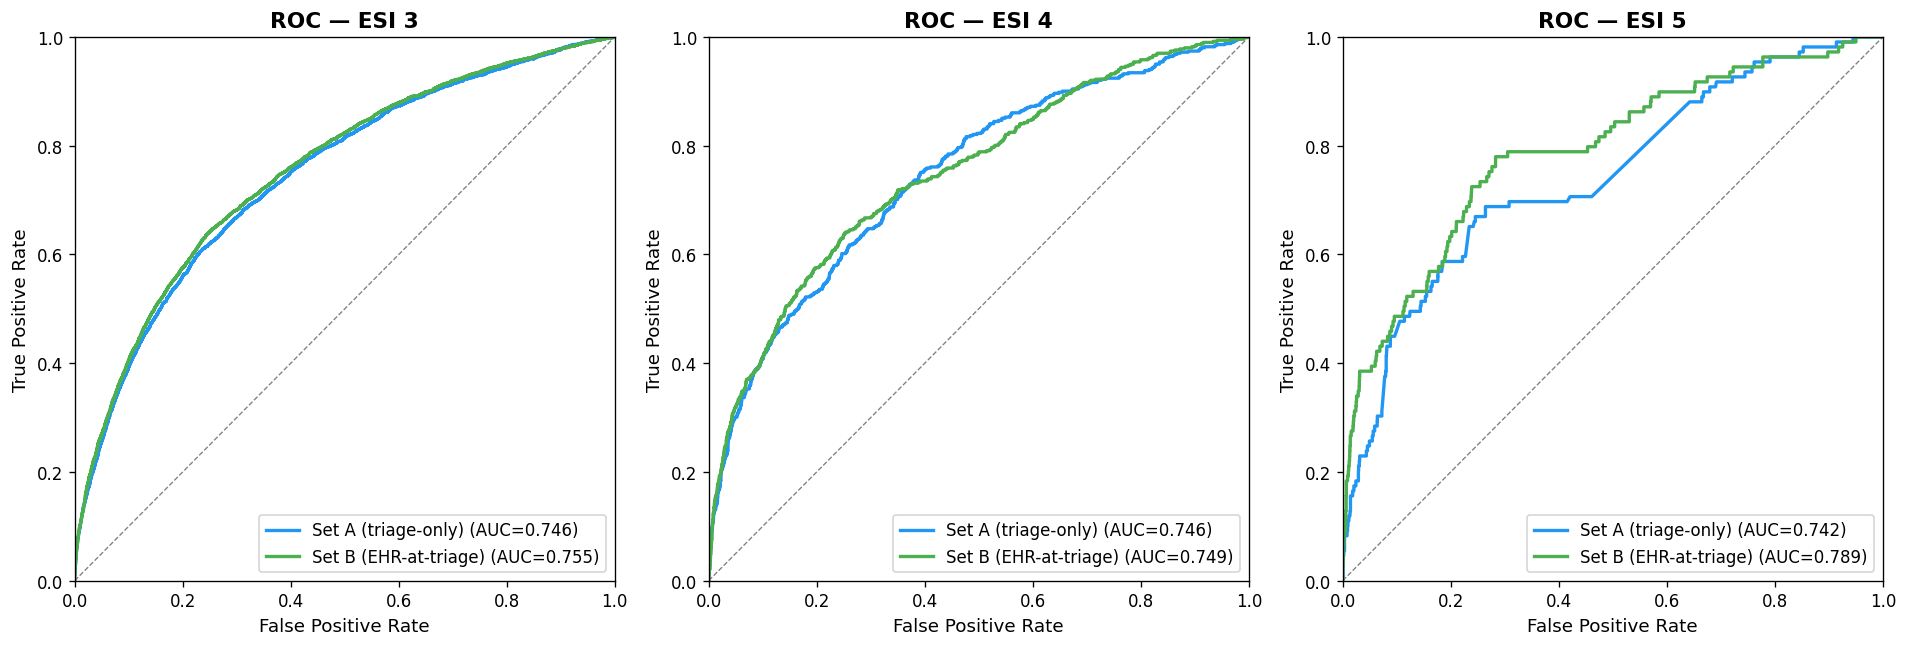

Saved: 02_roc_curves.png


In [13]:
# ROC curves per ESI
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (esi, df_esi) in zip(axes, [(3, df_3), (4, df_4), (5, df_5)]):
    y_true = df_esi['outcome'].values
    for label, oof, color in [
        ('Set A (triage-only)', oof_A[esi], '#2196F3'),
        ('Set B (EHR-at-triage)', oof_B[esi], '#4CAF50'),
    ]:
        valid = ~np.isnan(oof)
        fpr, tpr, _ = roc_curve(y_true[valid], oof[valid])
        auc = results_A[esi]['roc_auc'] if 'A' in label else results_B[esi]['roc_auc']
        ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, linewidth=2)
    ax.plot([0,1],[0,1],'--', color='gray', linewidth=0.8)
    ax.set_title(f'ROC — ESI {esi}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORT_DIR / '02_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_roc_curves.png')


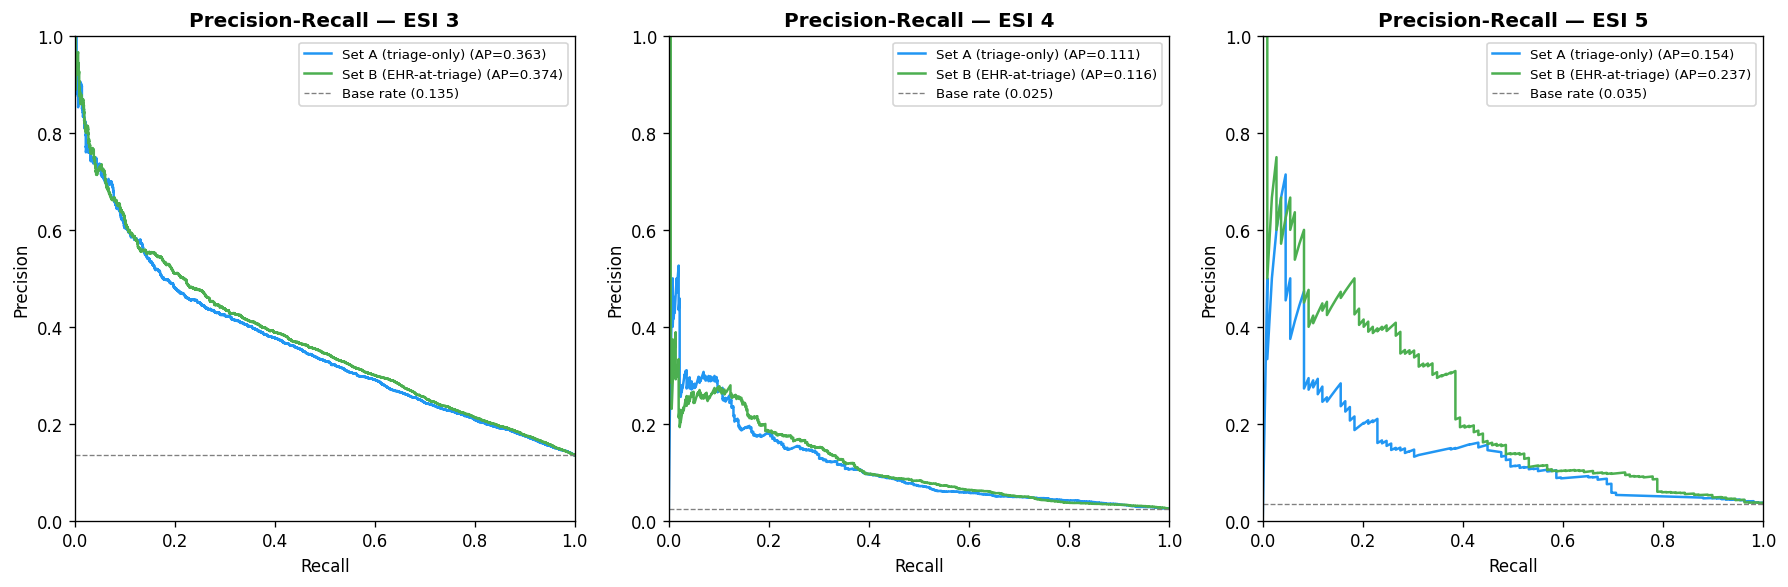

Saved: 02_pr_curves.png


In [14]:
# PR curves per ESI
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (esi, df_esi) in zip(axes, [(3, df_3), (4, df_4), (5, df_5)]):
    y_true   = df_esi['outcome'].values
    base_rate = y_true.mean()
    for label, oof, color in [
        ('Set A (triage-only)', oof_A[esi], '#2196F3'),
        ('Set B (EHR-at-triage)', oof_B[esi], '#4CAF50'),
    ]:
        valid = ~np.isnan(oof)
        prec, rec, _ = precision_recall_curve(y_true[valid], oof[valid])
        pr_val = results_A[esi]['pr_auc'] if 'A' in label else results_B[esi]['pr_auc']
        ax.plot(rec, prec, label=f'{label} (AP={pr_val:.3f})', color=color)
    ax.axhline(base_rate, color='gray', linestyle='--', linewidth=0.8,
               label=f'Base rate ({base_rate:.3f})')
    ax.set_title(f'Precision-Recall — ESI {esi}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORT_DIR / '02_pr_curves.png', bbox_inches='tight')
plt.show()
print('Saved: 02_pr_curves.png')


---
## Section 7 — Permutation Test: Is the Intra-ESI Signal Real?

For each ESI, we shuffle the outcome labels **within that ESI** 500 times and recompute the ROC AUC on the OOF predictions. If the real AUC is just an artifact of knowing the ESI assignment (rather than patient-level features), the shuffled AUC should match the real one.

**Decision rule:** if p ≥ 0.05 for any ESI, we declare absence of detectable intra-ESI signal for that group and do not proceed with alert policy in NB03.

**Historical reference (V1 on same NHAMCS pool):**  
ESI 3: Z=62.6 | ESI 4: Z=23.1 | ESI 5: Z=13.9 — all p<0.001

In [15]:
np.random.seed(RANDOM_STATE)
N_SHUFFLES = 500
perm_results = {}

print(f'Permutation test ({N_SHUFFLES} shuffles per ESI)')
print(f'{"ESI":<5}  {"Real AUC":<10}  {"Mean shuffled":<15}  '
      f'{"Z-score":<10}  {"p-value":<10}  {"Verdict"}')
print('-' * 75)

for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    y_true = df_esi['outcome'].values
    oof    = oof_A[esi]
    valid  = ~np.isnan(oof)
    y_v, p_v = y_true[valid], oof[valid]

    real_auc = roc_auc_score(y_v, p_v)

    shuffled_aucs = []
    for _ in range(N_SHUFFLES):
        y_shuf = y_v.copy()
        np.random.shuffle(y_shuf)
        if y_shuf.sum() > 0:
            shuffled_aucs.append(roc_auc_score(y_shuf, p_v))

    mean_shuf = np.mean(shuffled_aucs)
    std_shuf  = np.std(shuffled_aucs)
    z_score   = (real_auc - mean_shuf) / std_shuf if std_shuf > 0 else np.nan
    p_value   = (np.sum(np.array(shuffled_aucs) >= real_auc) + 1) / (N_SHUFFLES + 1)

    verdict = 'SIGNAL CONFIRMED (p<0.001)' if p_value < 0.001 else \
              'SIGNAL CONFIRMED (p<0.05)'  if p_value < 0.05  else \
              'NO DETECTABLE SIGNAL'

    perm_results[esi] = {
        'esi': esi, 'real_auc': round(real_auc, 4),
        'mean_shuffled': round(mean_shuf, 4), 'std_shuffled': round(std_shuf, 6),
        'z_score': round(z_score, 2), 'p_value': round(p_value, 6), 'verdict': verdict,
    }
    print(f'{esi:<5}  {real_auc:<10.4f}  {mean_shuf:<15.4f}  '
          f'{z_score:<10.2f}  {p_value:<10.6f}  {verdict}')

with open(REPORT_DIR / '02_permutation_test.json', 'w') as f:
    json.dump(perm_results, f, indent=2)
print('\nSaved: 02_permutation_test.json')


Permutation test (500 shuffles per ESI)
ESI    Real AUC    Mean shuffled    Z-score     p-value     Verdict
---------------------------------------------------------------------------


3      0.7462      0.5004           53.49       0.001996    SIGNAL CONFIRMED (p<0.05)


4      0.7456      0.5003           19.28       0.001996    SIGNAL CONFIRMED (p<0.05)


5      0.7424      0.4981           9.01        0.001996    SIGNAL CONFIRMED (p<0.05)

Saved: 02_permutation_test.json


---
## Section 8 — Model Explainability: SHAP Analysis (Set A)

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions. This is not an add-on — it is the mechanism by which the system generates actionable, clinically interpretable alerts.

The alert format is:
> *"⚠️ PRIORITIZATION ALERT — ESI [X]  
> This patient shows elevated risk of requiring hospitalization or transfer within their ESI category.  
> Identified risk factors: [top 3 clinical factors]  
> Suggested action: reassess earlier than scheduled for this category."*

SHAP is computed on models trained on the **full dataset** (no held-out), for global interpretability. Alert examples use the OOF scores for honest evaluation.

In [16]:
# Clinical name mapping — variable → readable English label
CLINICAL_NAMES = {
    'AGE':                  'advanced age',
    'age_65plus':           'older adult patient (≥65 years)',
    'age_shock_index':      'combined advanced age and hemodynamic instability',
    'shock_index':          'elevated shock index (HR/SBP)',
    'PULSE':                'elevated heart rate',
    'BPSYS':                'low systolic blood pressure',
    'POPCT':                'reduced oxygen saturation',
    'RESPR':                'elevated respiratory rate',
    'temp_f':               'abnormal temperature',
    'PAINSCALE':            'severe pain at presentation',
    'ARREMS':               'arrival by ambulance',
    'hypoxemia_flag':       'hypoxemia at presentation (SpO2 <94%)',
    'tachycardia_flag':     'tachycardia at presentation (HR >100)',
    'tachypnea_flag':       'tachypnea at presentation (RR >20)',
    'hypotension_flag':     'hypotension at presentation (SBP <90)',
    'fever_flag':           'fever at presentation (T >38°C)',
    'bp_missing_flag':      'blood pressure not recorded at triage',
    'any_vital_missing_flag': 'incomplete vital signs at triage',
    'comorbidity_count':    'high comorbidity burden',
    'CHF':                  'congestive heart failure',
    'COPD':                 'chronic obstructive pulmonary disease',
    'CANCER':               'history of cancer',
    'DIABTYP1':             'type 1 diabetes mellitus',
    'DIABTYP2':             'type 2 diabetes mellitus',
    'HTN':                  'hypertension',
    'ESRD':                 'end-stage renal disease',
    'ASTHMA':               'asthma',
    'DEPRN':                'depression',
    'EDHIV':                'HIV',
    'OBESITY':              'obesity',
    'SUBSTAB':              'substance use disorder',
    'SEX':                  'sex',
    'RFV1':                 'high-risk reason for visit',
    'RFV2':                 'secondary reason for visit',
    'BPDIAS':               'diastolic blood pressure',
}

def feature_to_label(feat_name):
    return CLINICAL_NAMES.get(feat_name, feat_name.replace('_', ' ').lower())

print('Clinical name mapping defined:', len(CLINICAL_NAMES), 'entries')


Clinical name mapping defined: 35 entries


In [17]:
# Train final models on full dataset for SHAP global interpretability
final_models = {}
shap_values_dict = {}

for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    n_pos = int(df_esi['outcome'].sum())
    n_neg = len(df_esi) - n_pos
    params = get_lgbm_params(n_neg, n_pos)

    model = lgb.LGBMClassifier(**params)
    model.fit(df_esi[FEATURES_A], df_esi['outcome'])
    final_models[esi] = model

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(df_esi[FEATURES_A])
    # For binary classifier, shap_values returns list [neg_class, pos_class]
    if isinstance(sv, list):
        sv = sv[1]
    shap_values_dict[esi] = sv

    df_sv = pd.DataFrame(sv, columns=FEATURES_A)
    df_sv.to_csv(REPORT_DIR / f'02_shap_values_esi{esi}.csv', index=False)
    print(f'ESI {esi}: SHAP computed and saved (shape={sv.shape})')

print('\nFinal models trained and SHAP values saved.')


ESI 3: SHAP computed and saved (shape=(31460, 22))


ESI 4: SHAP computed and saved (shape=(20182, 22))


ESI 5: SHAP computed and saved (shape=(3102, 22))

Final models trained and SHAP values saved.


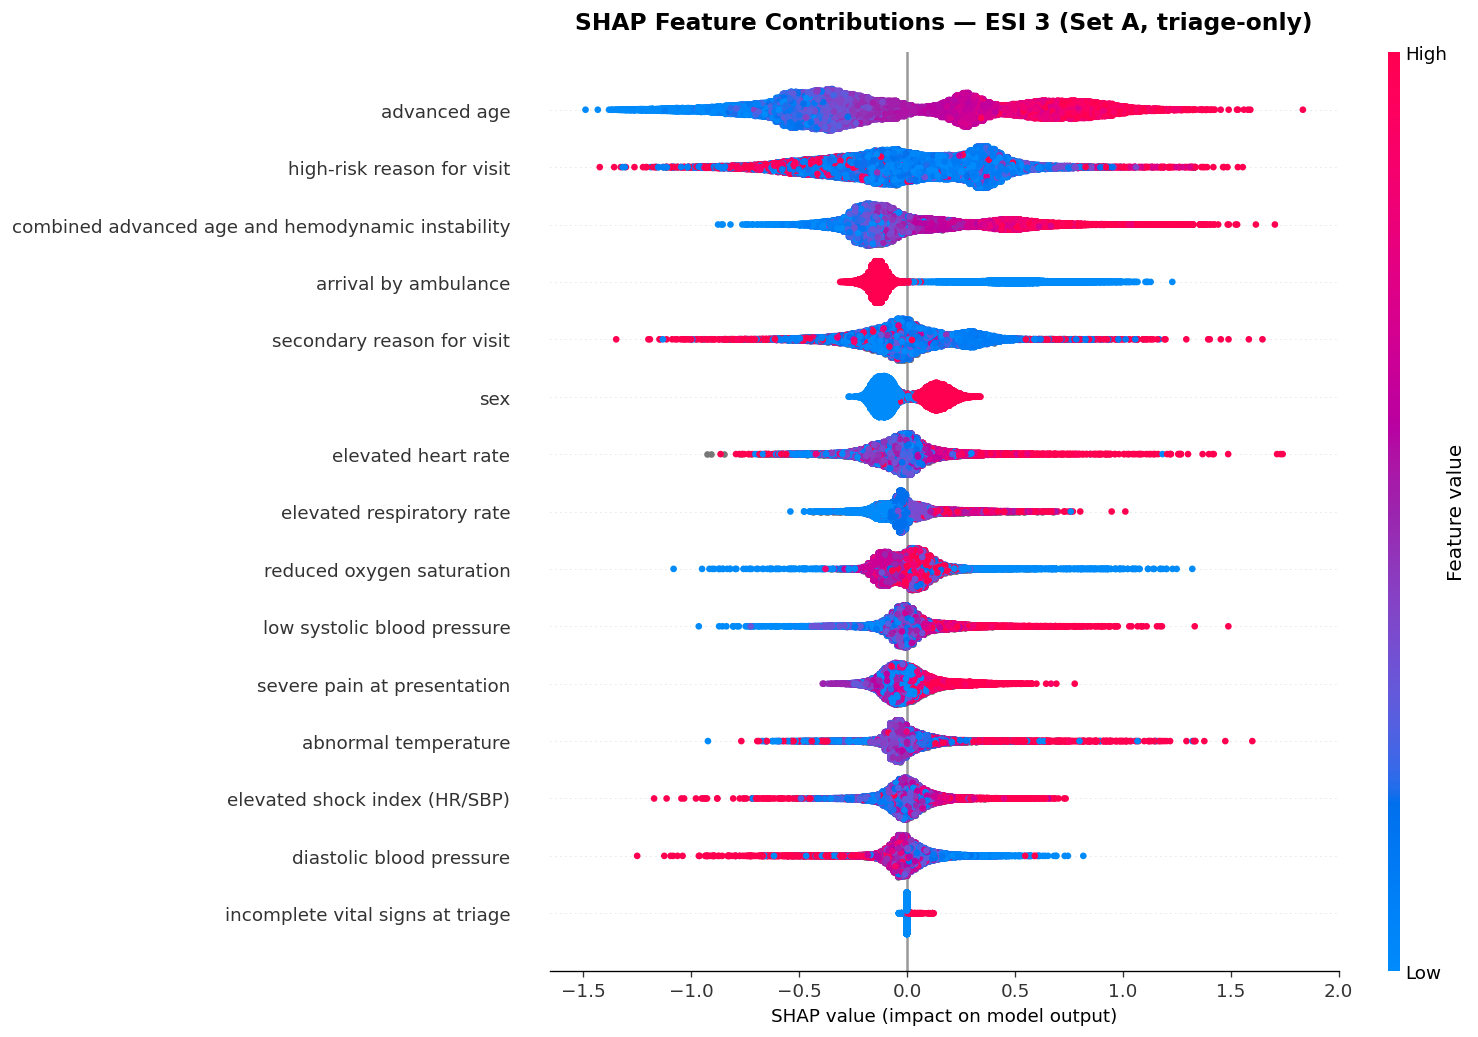

Saved: 02_shap_beeswarm_esi3.png


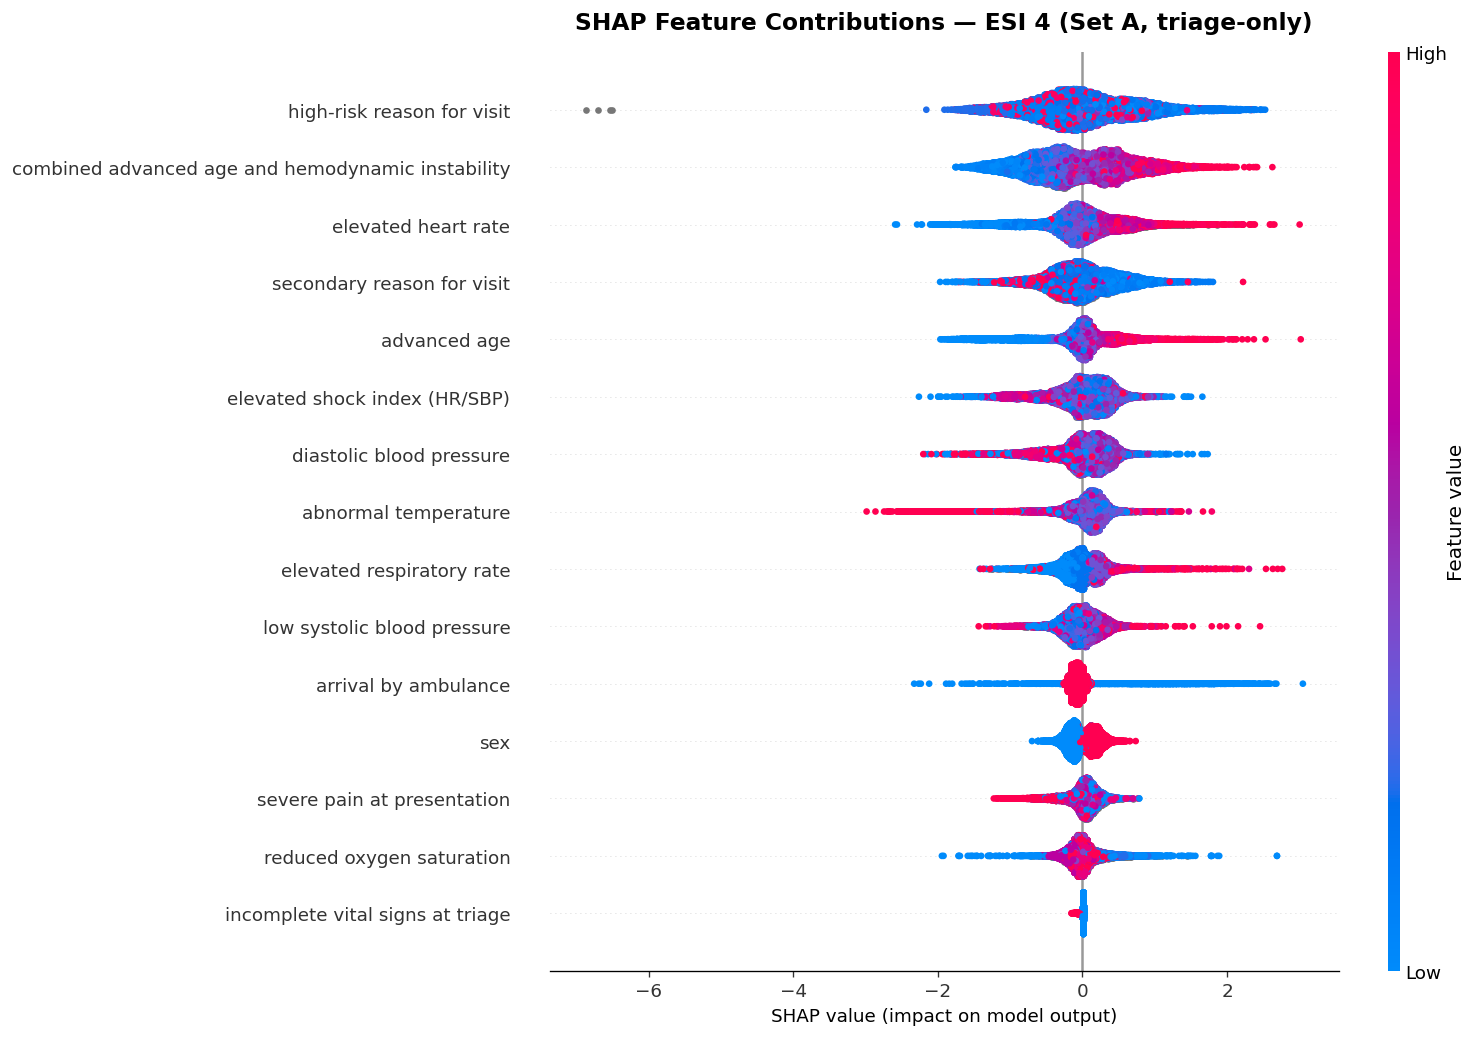

Saved: 02_shap_beeswarm_esi4.png


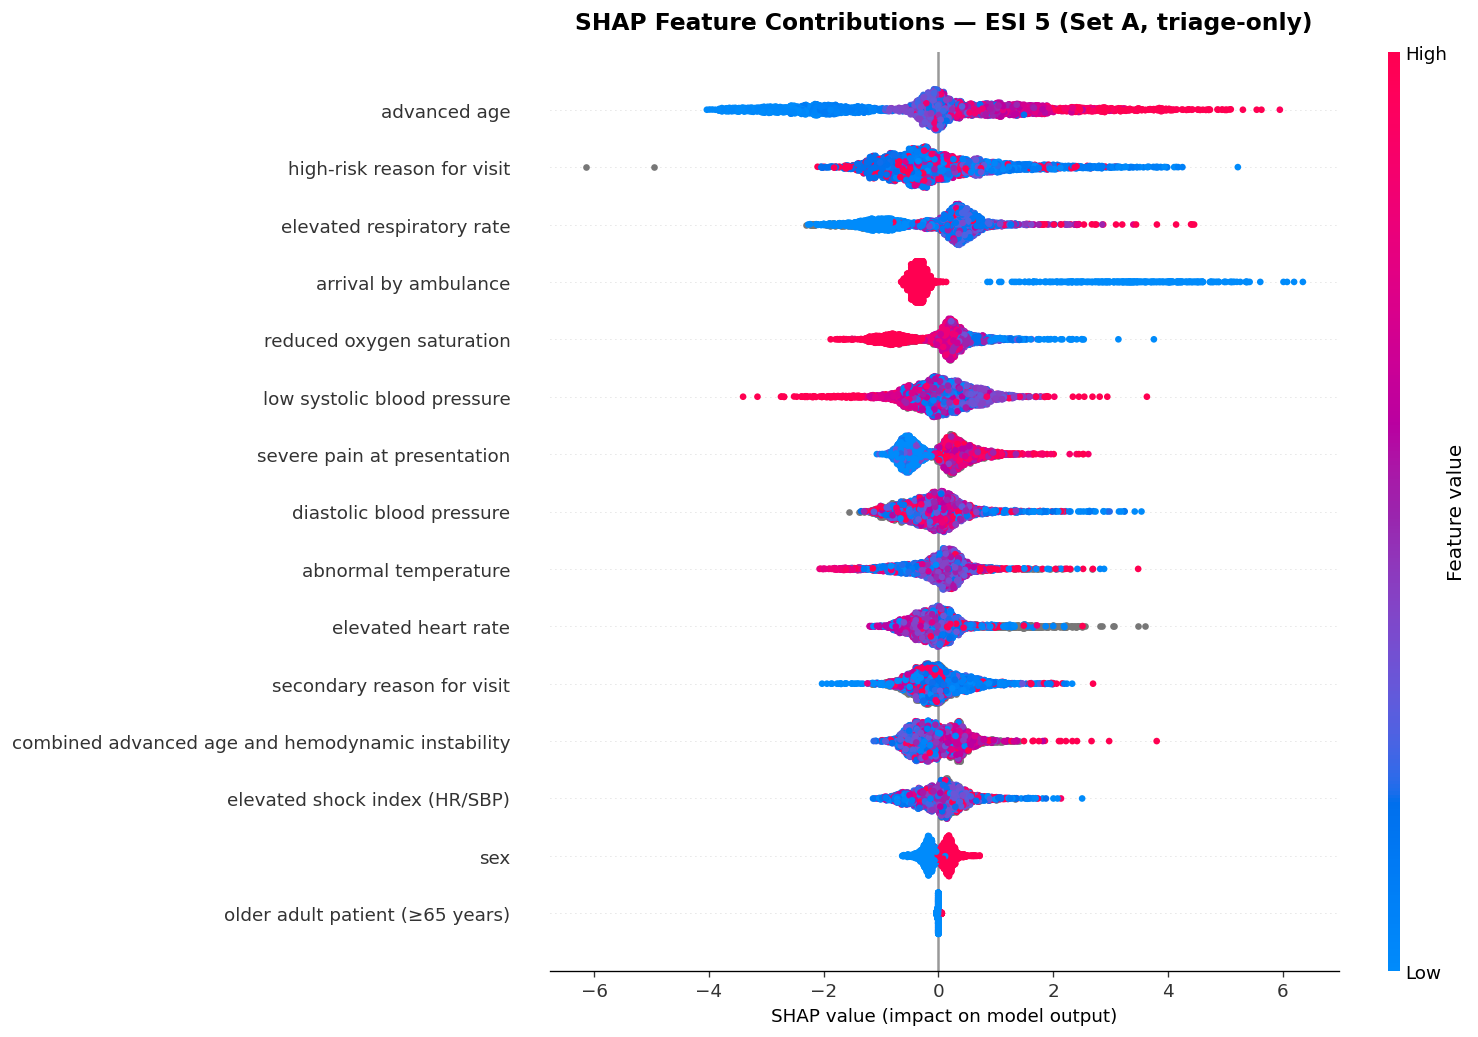

Saved: 02_shap_beeswarm_esi5.png


In [18]:
# SHAP summary (beeswarm) plots — one per ESI
for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    sv = shap_values_dict[esi]
    X  = df_esi[FEATURES_A]

    # Rename columns to clinical labels for the plot
    X_labeled = X.rename(columns=feature_to_label)
    feat_labels = [feature_to_label(f) for f in FEATURES_A]

    # plot_size is passed explicitly (width, height): shap.summary_plot ignores any
    # externally-created figure when plot_size=None and silently resizes the current
    # figure to its own narrow default, which crops the long clinical-language labels
    # used here (e.g. 'combined advanced age and hemodynamic instability').
    n_display = min(15, len(FEATURES_A))
    shap.summary_plot(
        sv, X_labeled,
        feature_names=feat_labels,
        max_display=15,
        show=False,
        plot_size=(13, n_display * 0.45 + 2),
    )
    fig = plt.gcf()
    for ax in fig.axes:
        ax.tick_params(labelsize=11)
        ax.xaxis.label.set_fontsize(11)
    plt.title(f'SHAP Feature Contributions — ESI {esi} (Set A, triage-only)',
              fontsize=14, fontweight='bold', pad=14)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f'02_shap_beeswarm_esi{esi}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: 02_shap_beeswarm_esi{esi}.png')


In [19]:
# Generate alert text for top-scoring OOF patients — ESI 4 examples
# (ESI 4 chosen: meaningful base rate, not already in immediate care circuit)

def generate_alert_text(esi, patient_row, oof_score, shap_row, features):
    """Generate English-language clinical alert for a single patient."""
    # Top 3 features with largest positive SHAP contribution
    shap_series = pd.Series(shap_row, index=features)
    top3 = shap_series.nlargest(3)
    factors = [f'- {feature_to_label(f)} (contribution: +{v:.3f})'
               for f, v in top3.items()]

    alert = (
        f'\u26a0\ufe0f PRIORITIZATION ALERT \u2014 ESI {esi}\n'
        f'Risk score: {oof_score:.3f} (population percentile: top {100*(1-oof_score):.0f}%)\n'
        f'This patient shows elevated risk of requiring hospitalization or transfer\n'
        f'within their ESI category.\n'
        f'Identified risk factors:\n'
        + '\n'.join(factors) +
        f'\nSuggested action: reassess earlier than scheduled for this category.'
    )
    return alert, top3

esi4_oof = oof_A[4].copy()
valid4 = ~np.isnan(esi4_oof)
sv4 = shap_values_dict[4]

# Select 3 ESI 4 true positives spanning the alert zone, anchored to the actual
# alert policy (NB03: ESI4 alert burden = top 5%, score >= ~95th percentile;
# confirmed against reports/03_alert_policy/03_final_policy.json: threshold_pct=5,
# score_cutoff=0.5531). Rather than showing only the single most extreme cases
# (which collapse to ~99.9th percentile and look identical), we pick true
# positives near three percentiles WITHIN the alert zone (99 / 97 / 95.5) so the
# examples demonstrate that the system grades risk, not just flags the top —
# while every example shown is still a patient the policy would actually alert.
cohort_scores = esi4_oof[valid4]
alert_cutoff  = np.percentile(cohort_scores, 95)  # top 5% burden, matches NB03 ESI4 policy

def percentile_of(score):
    return (cohort_scores <= score).mean() * 100

mask_tp_alert = (df_4['outcome'].values == 1) & valid4 & (esi4_oof >= alert_cutoff)
tp_alert_idx  = np.where(mask_tp_alert)[0]

TARGET_PERCENTILES = [99.0, 97.0, 95.5]
chosen_idx = []
for target in TARGET_PERCENTILES:
    dists = np.array([abs(percentile_of(esi4_oof[i]) - target) for i in tp_alert_idx])
    chosen_idx.append(tp_alert_idx[np.argmin(dists)])

print(f'Alert cutoff (top 5% burden): score >= {alert_cutoff:.4f}')
print(f'True positives in alert zone: {mask_tp_alert.sum()}')
for target, idx in zip(TARGET_PERCENTILES, chosen_idx):
    print(f'  target percentile {target:>5.1f}  ->  actual {percentile_of(esi4_oof[idx]):.2f}  '
          f'(score={esi4_oof[idx]:.4f})')
print()

alert_rows = []
enriched_rows = []
print('=== CLINICAL ALERT EXAMPLES — ESI 4, Graded Risk Within the Alert Zone ===\n')
for i, idx in enumerate(chosen_idx):
    row      = df_4.iloc[idx]
    score    = esi4_oof[idx]
    shap_row = sv4[idx]
    alert_txt, top3 = generate_alert_text(4, row, score, shap_row, FEATURES_A)
    top3_feats = list(top3.index)

    print(f'--- Example {i+1} ---')
    print(f'Patient: Age={int(row["AGE"])}, '
          f'SpO2={row["POPCT"]}%, Pulse={row["PULSE"]}, '
          f'SBP={row["BPSYS"]}, Comorbidities={int(row["comorbidity_count"])}')
    print(f'Outcome: HOSPITALIZED={int(row["ADMITHOS"])}, '
          f'TRANSFER={int(row["TRANOTH"])}, DIED={int(row["DIEDED"])}')
    print(alert_txt)
    print()

    alert_rows.append({
        'example': i+1, 'esi': 4, 'idx': idx, 'oof_score': round(score, 4),
        'outcome': int(row['outcome']), 'AGE': int(row['AGE']),
        'POPCT': row['POPCT'], 'PULSE': row['PULSE'], 'BPSYS': row['BPSYS'],
        'top1_feature': top3_feats[0], 'top2_feature': top3_feats[1],
        'top3_feature': top3_feats[2],
        'alert_text': alert_txt,
    })

    # Enriched export: adds raw RFV codes (NB05 translates these into chief-complaint
    # text) and per-feature SHAP values alongside the same alert row.
    enriched_rows.append({
        'example': i+1, 'idx': idx, 'oof_score': round(score, 4),
        'outcome': int(row['outcome']), 'ADMITHOS': int(row['ADMITHOS']),
        'TRANOTH': int(row['TRANOTH']), 'DIEDED': int(row['DIEDED']),
        'AGE': row['AGE'], 'SEX': row['SEX'], 'ARREMS': row['ARREMS'],
        'PULSE': row['PULSE'], 'BPSYS': row['BPSYS'], 'BPDIAS': row['BPDIAS'],
        'POPCT': row['POPCT'], 'RESPR': row['RESPR'], 'temp_f': row['temp_f'],
        'PAINSCALE': row['PAINSCALE'], 'shock_index': row['shock_index'],
        'RFV1_code': row['RFV1'], 'RFV2_code': row['RFV2'],
        'comorbidity_count': int(row['comorbidity_count']),
        'top1_feat': top3_feats[0], 'top1_shap': round(float(top3.iloc[0]), 4),
        'top2_feat': top3_feats[1], 'top2_shap': round(float(top3.iloc[1]), 4),
        'top3_feat': top3_feats[2], 'top3_shap': round(float(top3.iloc[2]), 4),
        'alert_text': alert_txt,
    })

pd.DataFrame(alert_rows).to_csv(REPORT_DIR / '02_alert_examples_esi4.csv', index=False)
print('Saved: 02_alert_examples_esi4.csv')

pd.DataFrame(enriched_rows).to_csv(REPORT_DIR / '02_alert_examples_enriched.csv', index=False)
print('Saved: 02_alert_examples_enriched.csv')


Alert cutoff (top 5% burden): score >= 0.5531
True positives in alert zone: 145
  target percentile  99.0  ->  actual 99.03  (score=0.7783)
  target percentile  97.0  ->  actual 96.95  (score=0.6362)
  target percentile  95.5  ->  actual 95.51  (score=0.5736)

=== CLINICAL ALERT EXAMPLES — ESI 4, Graded Risk Within the Alert Zone ===

--- Example 1 ---
Patient: Age=52, SpO2=100.0%, Pulse=111.0, SBP=185.0, Comorbidities=1
Outcome: HOSPITALIZED=1, TRANSFER=0, DIED=0
⚠️ PRIORITIZATION ALERT — ESI 4
Risk score: 0.778 (population percentile: top 22%)
This patient shows elevated risk of requiring hospitalization or transfer
within their ESI category.
Identified risk factors:
- arrival by ambulance (contribution: +1.990)
- elevated respiratory rate (contribution: +1.494)
- high-risk reason for visit (contribution: +1.218)
Suggested action: reassess earlier than scheduled for this category.

--- Example 2 ---
Patient: Age=92, SpO2=99.0%, Pulse=99.0, SBP=138.0, Comorbidities=2
Outcome: HOSPITAL

---
## Section 9 — Interpretation Note: ESI 5

ESI 5 results should be interpreted with caution due to its smaller sample size (N=3,102; 109 positive outcomes), which produces wider confidence intervals and lower statistical precision than ESI 3 and 4.

We also note, as an open observation, that the base rate of serious outcomes in ESI 5 (3.5%) is higher than in ESI 4 (2.5%). We report this pattern without attributing a cause, as the present data do not allow us to determine its origin.

Operational use of the ESI 5 model should weigh the lower statistical precision against the clinical context of each deployment setting.

---
## Section 10 — Alert Burden Analysis

Alert burden is reported as percentage of ESI patients flagged. **NHAMCS is a national probability sample with visit weights (PATWT), not a hospital log.** Operationalized per-shift figures are illustrative simulations only.

In [20]:
print('=== ALERT BURDEN BY THRESHOLD (Set A, OOF scores) ===')
print()

burden_rows = []
for esi, df_esi in [(3, df_3), (4, df_4), (5, df_5)]:
    y_true    = df_esi['outcome'].values
    oof       = oof_A[esi]
    valid     = ~np.isnan(oof)
    y_v, p_v  = y_true[valid], oof[valid]
    base_rate = y_v.mean()
    n_total   = valid.sum()

    print(f'ESI {esi}  (N={n_total:,}, base rate={base_rate:.3f})')
    print(f'  {"Threshold":<12}  {"N alerted":>10}  {"Burden%":>8}  '
          f'{"PPV":>7}  {"Enrichment":>11}  {"Recall":>8}')
    for pct in [5, 10, 15, 20]:
        thresh  = np.percentile(p_v, 100 - pct)
        flagged = p_v >= thresh
        n_flag  = flagged.sum()
        ppv     = y_v[flagged].mean() if n_flag > 0 else 0
        enrich  = ppv / base_rate if base_rate > 0 else 0
        recall  = y_v[flagged].sum() / y_v.sum() if y_v.sum() > 0 else 0
        print(f'  Top {pct}%       {n_flag:>10,}  {n_flag/n_total*100:>8.1f}%  '
              f'{ppv:>7.3f}  {enrich:>11.2f}x  {recall:>8.3f}')
        burden_rows.append({
            'esi': esi, 'threshold_pct': pct, 'n_alerted': int(n_flag),
            'burden_pct': round(n_flag/n_total*100, 1),
            'ppv': round(ppv, 4), 'base_rate': round(base_rate, 4),
            'enrichment': round(enrich, 3), 'recall': round(recall, 3),
        })
    print()

pd.DataFrame(burden_rows).to_csv(REPORT_DIR / '02_alert_burden.csv', index=False)
print('Saved: 02_alert_burden.csv')
print()
print('Hypothetical operational example (illustrative, not actual service volume):')
print('In a service with 50 ESI 4 patients per shift, a Top 10% policy would generate')
print('~5 alerts per shift. This figure depends entirely on actual service volume.')


=== ALERT BURDEN BY THRESHOLD (Set A, OOF scores) ===

ESI 3  (N=31,460, base rate=0.135)
  Threshold      N alerted   Burden%      PPV   Enrichment    Recall
  Top 5%            1,573       5.0%    0.498         3.69x     0.184
  Top 10%            3,146      10.0%    0.420         3.11x     0.311
  Top 15%            4,719      15.0%    0.372         2.76x     0.413
  Top 20%            6,292      20.0%    0.332         2.46x     0.492

ESI 4  (N=20,182, base rate=0.025)
  Threshold      N alerted   Burden%      PPV   Enrichment    Recall
  Top 5%            1,010       5.0%    0.144         5.77x     0.289
  Top 10%            2,019      10.0%    0.098         3.94x     0.394
  Top 15%            3,028      15.0%    0.078         3.15x     0.472
  Top 20%            4,037      20.0%    0.065         2.63x     0.526

ESI 5  (N=3,102, base rate=0.035)
  Threshold      N alerted   Burden%      PPV   Enrichment    Recall
  Top 5%              156       5.0%    0.160         4.56x     0.

---
## Section 11 — Output Artifacts Summary

In [21]:
import os
print('=== ARTIFACTS SAVED IN reports/02_model_validation/ ===')
for f in sorted(REPORT_DIR.iterdir()):
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f.name:<45}  {size_kb:>8.1f} KB')

print()
print('Key outputs for downstream notebooks:')
print('  NB03 (Alert Policy):')
print('    02_oof_predictions_esi{3,4,5}.csv — scores for threshold calibration')
print('    02_baselines_clinical_rules.csv   — reference enrichment to beat')
print('    02_alert_burden.csv               — burden vs enrichment trade-off')
print('  NB04 (Subgroups & Fairness):')
print('    02_shap_values_esi{3,4,5}.csv     — per-patient SHAP for subgroup analysis')
print('    02_oof_predictions_esi{3,4,5}.csv — scores for demographic stratification')
print('  NB05 (Kaggle Submission):')
print('    02_metrics_summary.json           — final metrics table')
print('    02_permutation_test.json          — statistical validation')
print('    02_alert_examples_esi4.csv        — narrative examples')


=== ARTIFACTS SAVED IN reports/02_model_validation/ ===
  02_alert_burden.csv                                 0.6 KB
  02_alert_examples_enriched.csv                      1.9 KB
  02_alert_examples_esi4.csv                          1.6 KB
  02_baselines_clinical_rules.csv                     1.1 KB
  02_metrics_summary.json                             3.1 KB
  02_oof_predictions_esi3.csv                      1236.9 KB
  02_oof_predictions_esi4.csv                       799.3 KB
  02_oof_predictions_esi5.csv                       125.1 KB
  02_permutation_test.json                            0.6 KB
  02_pr_curves.png                                   76.5 KB
  02_roc_curves.png                                 119.4 KB
  02_shap_beeswarm_esi3.png                         338.8 KB
  02_shap_beeswarm_esi4.png                         282.0 KB
  02_shap_beeswarm_esi5.png                         292.7 KB
  02_shap_values_esi3.csv                         10975.4 KB
  02_shap_values_esi4.csv    